# Analysis of a Serial Quantum Fourier model results
Compatible with Qiskit 1.2.4+

### Author
- **Jacob Cybulski**, jacob.cybulski[at]deakin.edu.au<br/>
    School of IT, SEBE, Deakin University, Melbourne, Vic, Australia

### Date
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation. In association with IEEE Conference Trends in Quantum Computing and Emerging Business Technologies - TQCEBT 2022
- May 2024: Compatibility upgrade to Qiskit 1.02
- October 2024: Compatibility with Qiskit 1.2.4+ (ML 0.7.2, so no V2)
- Feb 2025: Addition of model instances

### Aims
> *This script aims to create a parallel variational model to fit data and provide a forecast.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

### Primary Sources
- Schuld, Maria, Ryan Sweke, and Johannes Jakob Meyer. 
    "The Effect of Data Encoding on the Expressive Power of Variational Quantum Machine Learning Models." 
    *Physical Review A 103*, no. 3 (March 24, 2021): 032430.<br/> 
    http://arxiv.org/abs/2008.08605<br/>
- PennyLane Dev Team. "Quantum models as Fourier series", Last updated: 15 Jan 2021.<br/>
    https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series.html

In [1]:
import sys
sys.path.append('.')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.']

In [2]:
import numpy as np
import pylab
import math
import json
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Target import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

In [3]:
### Libraries used in QTSA development

from IPython.display import clear_output
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit
from qiskit_algorithms.optimizers import L_BFGS_B, P_BFGS, COBYLA, NELDER_MEAD, QNSPSA, ADAM, UMDA
from qiskit.circuit.library import RealAmplitudes, TwoLocal, ZFeatureMap, ZZFeatureMap
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_algorithms.utils import algorithm_globals
from qiskit.visualization import plot_histogram, plot_state_city, plot_state_paulivec
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit.circuit import Parameter
from qiskit.compiler import transpile

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Setup the environment

In [4]:
### Listing control
debug = True

### Software version
MAJOR = 9
MINOR = 12

### Log path constants
LOG_NAME = 'log_4_iter'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('log_4_iter',
 'log_4_iter/data',
 'log_4_iter/training',
 'log_4_iter/analysis',
 'log_4_iter/figures')

## Fetch all training meta-data
**<font color="red">Enter the name of the DATA_ID</font>**<br/>
*Note that this is flat TS data*

In [5]:
### All created files have the following codes:
DATA_ID = '2_sins_t50_v20_z0.0_w0_s0_h0'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_fpath = f'{DATA_PATH}/{DATA_ID}/x_train.arr'
y_train_fpath = f'{DATA_PATH}/{DATA_ID}/y_train.arr'
x_valid_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid.arr'
y_valid_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'log_4_iter/data/2_sins_t50_v20_z0.0_w0_s0_h0/info.json'

In [6]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "log_4_iter/data/2_sins_t50_v20_z0.0_w0_s0_h0/info.json":

	info[data_name] = 2_sins
	info[major_version] = 8
	info[minor_version] = 10
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0.0
	info[wind_size] = 0
	info[wind_step] = 0
	info[wind_horizon] = 0
	info[seed] = 1770

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [7]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train = read_ts_file(x_train_fpath)[..., None]
y_train = read_ts_file(y_train_fpath)
X_valid = read_ts_file(x_valid_fpath)[..., None]
y_valid = read_ts_file(y_valid_fpath)
print(f'\nLoaded time series data\n')


Loaded time series data



## Fetch all training meta-data
**<font color="red">Enter the name of the TRAIN_ID</font>**

In [8]:
### Training directory prefix

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   l: number of layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs
TRAIN_ID = '2_sins_serial_n70_z0.0_q1_l15_L_BFGS_B_ep60'
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/info.json'
train_info_fpath

'log_4_iter/training/2_sins_serial_n70_z0.0_q1_l15_L_BFGS_B_ep60/info.json'

In [9]:
## Fetch all training parameters
### Reading the info file
train_info = read_json_file(train_info_fpath)

print(f'\nLoaded QTSA from a file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\ttrain_info[{k}] = {train_info[k]}')
print()

### Get info details
CASE_NAME = train_info['case_name']
DATA_NAME = train_info['data_name']
MAJOR = train_info['major_version'] 
MINOR = train_info['minor_version']
samples = train_info['data_sample']
train_pc = train_info['data_split']
noise = train_info['data_noise']

qubits = train_info['ansatz_qubits']
layers = train_info['ansatz_layers']
log_interv = train_info['log_interv']
opt_name = train_info['opt_name']
epochs = train_info['epochs']
shots = train_info['shots']
seed = train_info['seed']
inst_no = train_info['inst_no']
inst_seeds = train_info['inst_seeds']


Loaded QTSA from a file "log_4_iter/training/2_sins_serial_n70_z0.0_q1_l15_L_BFGS_B_ep60/info.json":

	train_info[data_name] = 2_sins
	train_info[case_name] = serial
	train_info[major_version] = 9
	train_info[minor_version] = 12
	train_info[data_sample] = 70
	train_info[data_split] = 0.7142857142857143
	train_info[data_noise] = 0.0
	train_info[ansatz_qubits] = 1
	train_info[ansatz_layers] = 15
	train_info[log_interv] = 1
	train_info[opt_name] = L_BFGS_B
	train_info[epochs] = 60
	train_info[shots] = 10000
	train_info[seed] = 2022
	train_info[inst_no] = 10
	train_info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Plot data

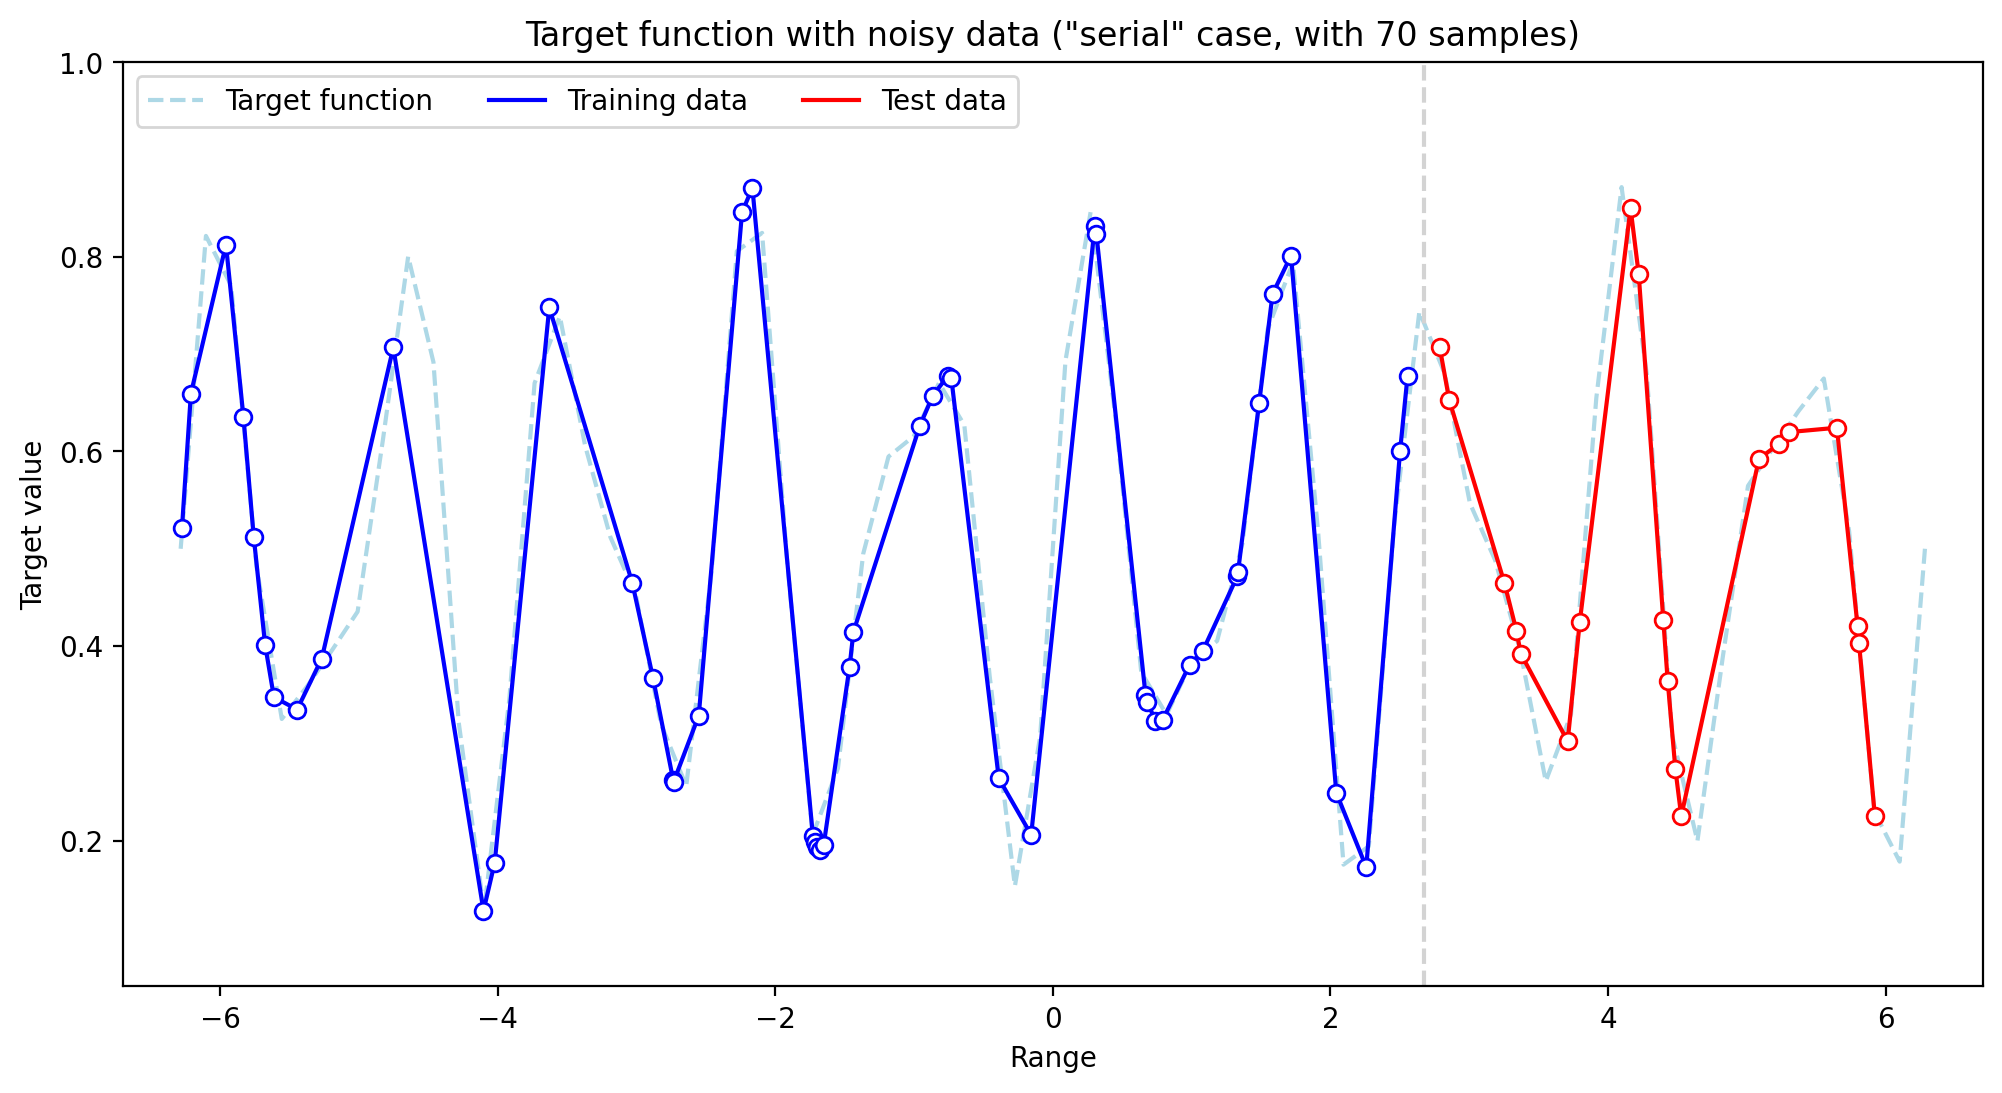

In [10]:
##### Plot data
plot_train_and_test_data(
    X_all, y_all, X_train, y_train, X_valid, y_valid, marker='o',
    xlim=(-6.7, 6.7), ylim=(0.05, 1), rcParams=(12, 6), dpi=200,
    colors=['lightblue', 'blue', 'red', 'blue', 'red'], linestyles=['dashed', 'solid', 'solid'],
    title=f'Target function with noisy data ("{CASE_NAME}" case, with {samples} samples)'
)

## Fetch all training parameters and cost history

In [11]:
### Reconstruct training prefix
ANALYSIS_PREF = TRAIN_ID

In [12]:
### Collect all instance numbers
inst_list = []
for sel_inst in range(inst_no):
    
    ### Training info files 
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.arr'
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.arr'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.arr'

    ### Check if any of the files are missing
    if  not if_path_exists(init_fpath) or \
        not if_path_exists(history_fpath) or \
        not if_path_exists(params_fpath):
        print(f'*** ERROR: Incomplete instance: {os.path.basename(os.path.dirname(init_fpath))}')
    else:
        inst_list.append(sel_inst)

print(f'\nFound instances: {inst_list}\n')


Found instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [13]:
### Initialise all instance lists
insts_init_weights = []
insts_objfun_vals = []
insts_params_vect = []

### Collect all instance data
for sel_inst in inst_list:
    
    ### Training info files 
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.arr'
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.arr'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.arr'

    ### Read training data
    init_weights = read_ts_file(init_fpath)
    objfun_vals = read_ts_file(history_fpath)
    params_vals = read_ts_file(params_fpath)
    insts_init_weights.append(init_weights)
    insts_objfun_vals.append(objfun_vals)
    insts_params_vect.append(params_vals)

print(f'\nCollected instances: {inst_list}\n')


Collected instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



## Load all analysis data

In [14]:
print(f'\nLoaded model scores for instances: ', end='')

inst_no = len(inst_list)

### Init predictions for all instances
insts_train_preds = [[]] * inst_no
insts_test_preds = [[]] * inst_no

### Init scores
insts_train_mae_scores = [[]] * inst_no
insts_train_mse_scores = [[]] * inst_no
insts_train_r2_scores = [[]] * inst_no
insts_test_mae_scores = [[]] * inst_no
insts_test_mse_scores = [[]] * inst_no
insts_test_r2_scores = [[]] * inst_no

for inst_idx in range(len(inst_list)):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Training info files 
    train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.arr'
    train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.arr'
    train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.arr'
    train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.arr'

    test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.arr'
    test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.arr'
    test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.arr'
    test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.arr'

    ### Read the scores
    insts_train_preds[inst_idx] = read_ts_file(train_preds_fpath)
    insts_train_mae_scores[inst_idx] = read_ts_file(train_mae_scores_fpath)
    insts_train_mse_scores[inst_idx] = read_ts_file(train_mse_scores_fpath)
    insts_train_r2_scores[inst_idx] = read_ts_file(train_r2_scores_fpath)

    insts_test_preds[inst_idx] = read_ts_file(test_preds_fpath)
    insts_test_mae_scores[inst_idx] = read_ts_file(test_mae_scores_fpath)
    insts_test_mse_scores[inst_idx] = read_ts_file(test_mse_scores_fpath)
    insts_test_r2_scores[inst_idx] = read_ts_file(test_r2_scores_fpath)

    print(f'{sel_inst} ', end='')

print('\n')


Loaded model scores for instances: 0 1 2 3 4 5 6 7 8 9 



## Plot the analysis results

## Plot the training cost (MSE) of all individual instances

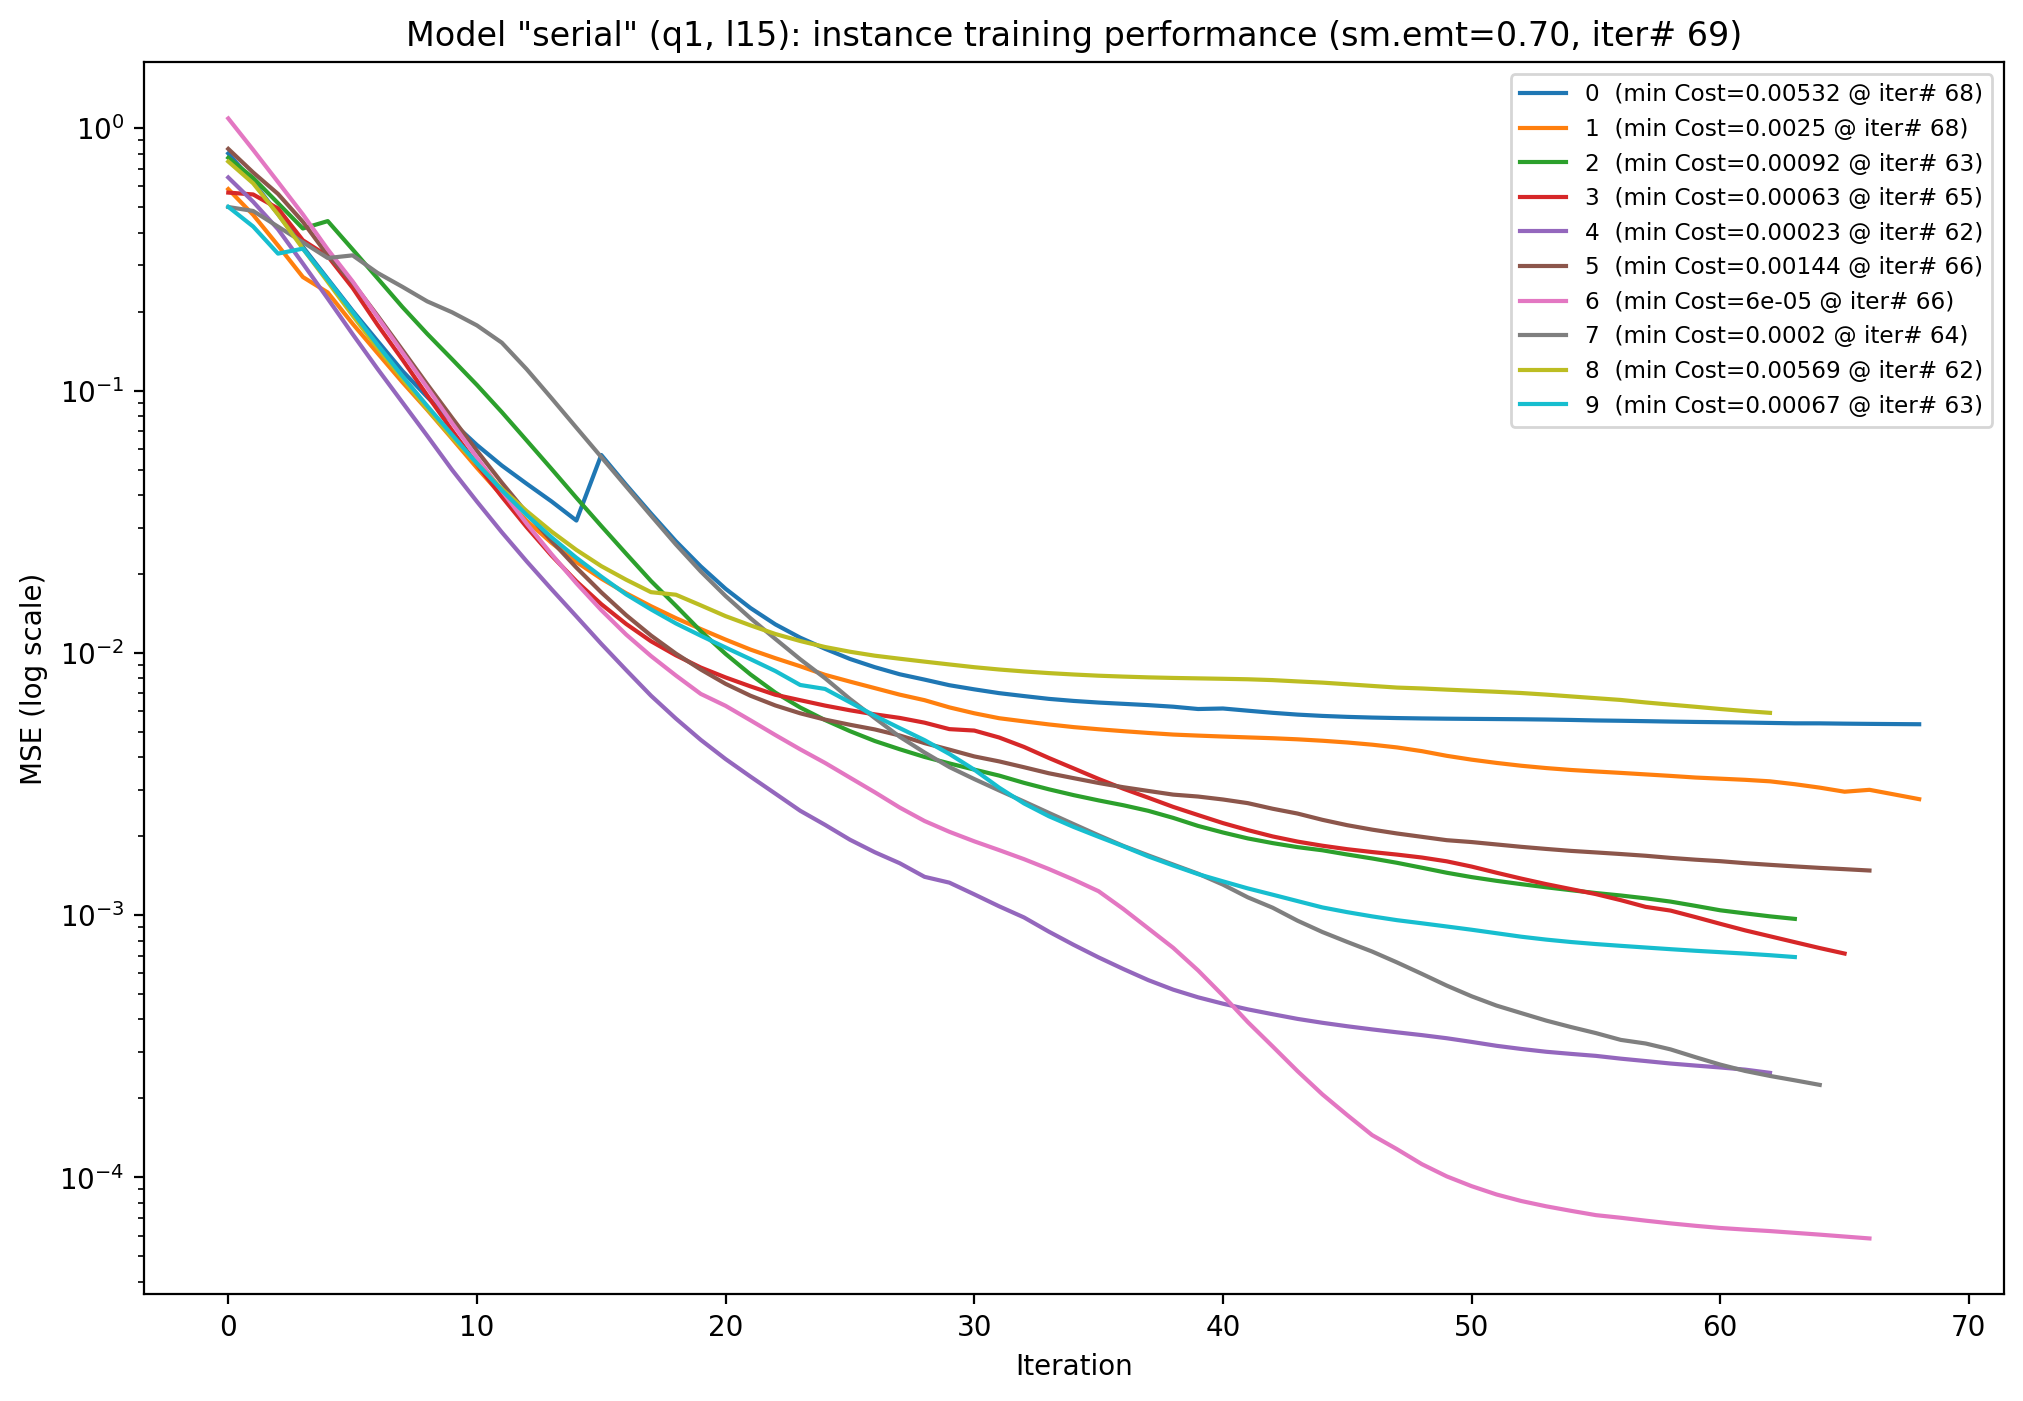

In [15]:
### Plot all trained instances
log_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_l{layers}_inst_train_perform_log.eps'
multi_perform_plot(insts_train_mse_scores, log_interv=log_interv, smooth_weight=0.7, 
    rcParams=(12, 8), dpi=200, yscale='log', ylabel=f'MSE (log scale)',
    title=f'Model "{CASE_NAME}" (q{qubits}, l{layers}): instance training performance', 
    labels=inst_list, save_plot=log_plot_path
    )

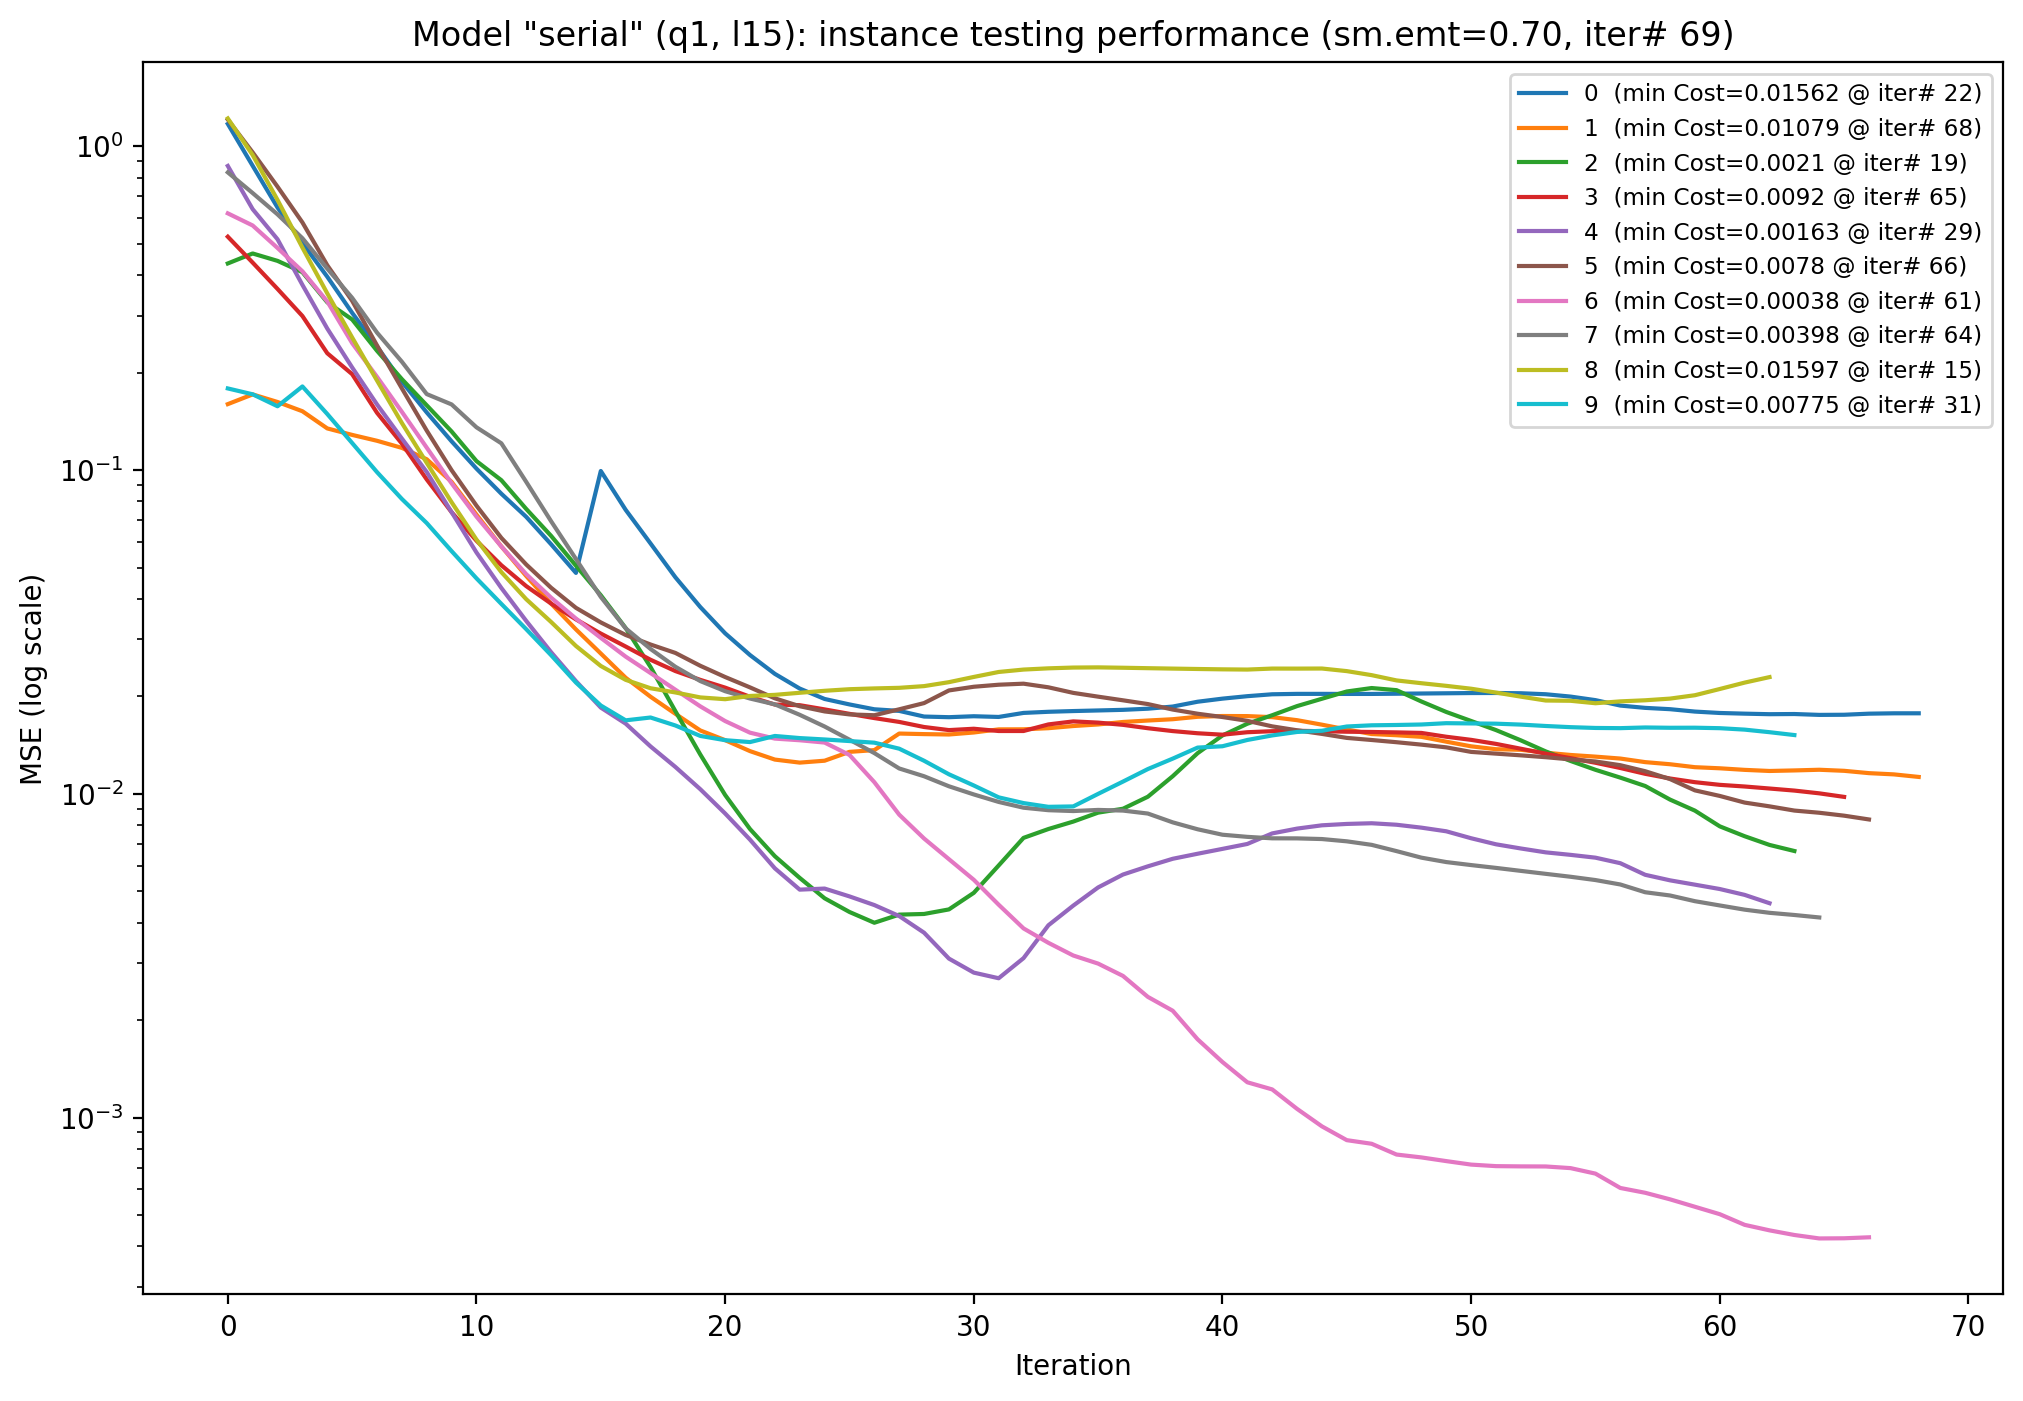

In [16]:
### Plot all trained instances
log_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_l{layers}_inst_test_perform_log.eps'
multi_perform_plot(insts_test_mse_scores, log_interv=log_interv, smooth_weight=0.7, 
    rcParams=(12, 8), dpi=200, yscale='log', ylabel=f'MSE (log scale)',
    title=f'Model "{CASE_NAME}" (q{qubits}, l{layers}): instance testing performance', 
    labels=inst_list, save_plot=log_plot_path
    )

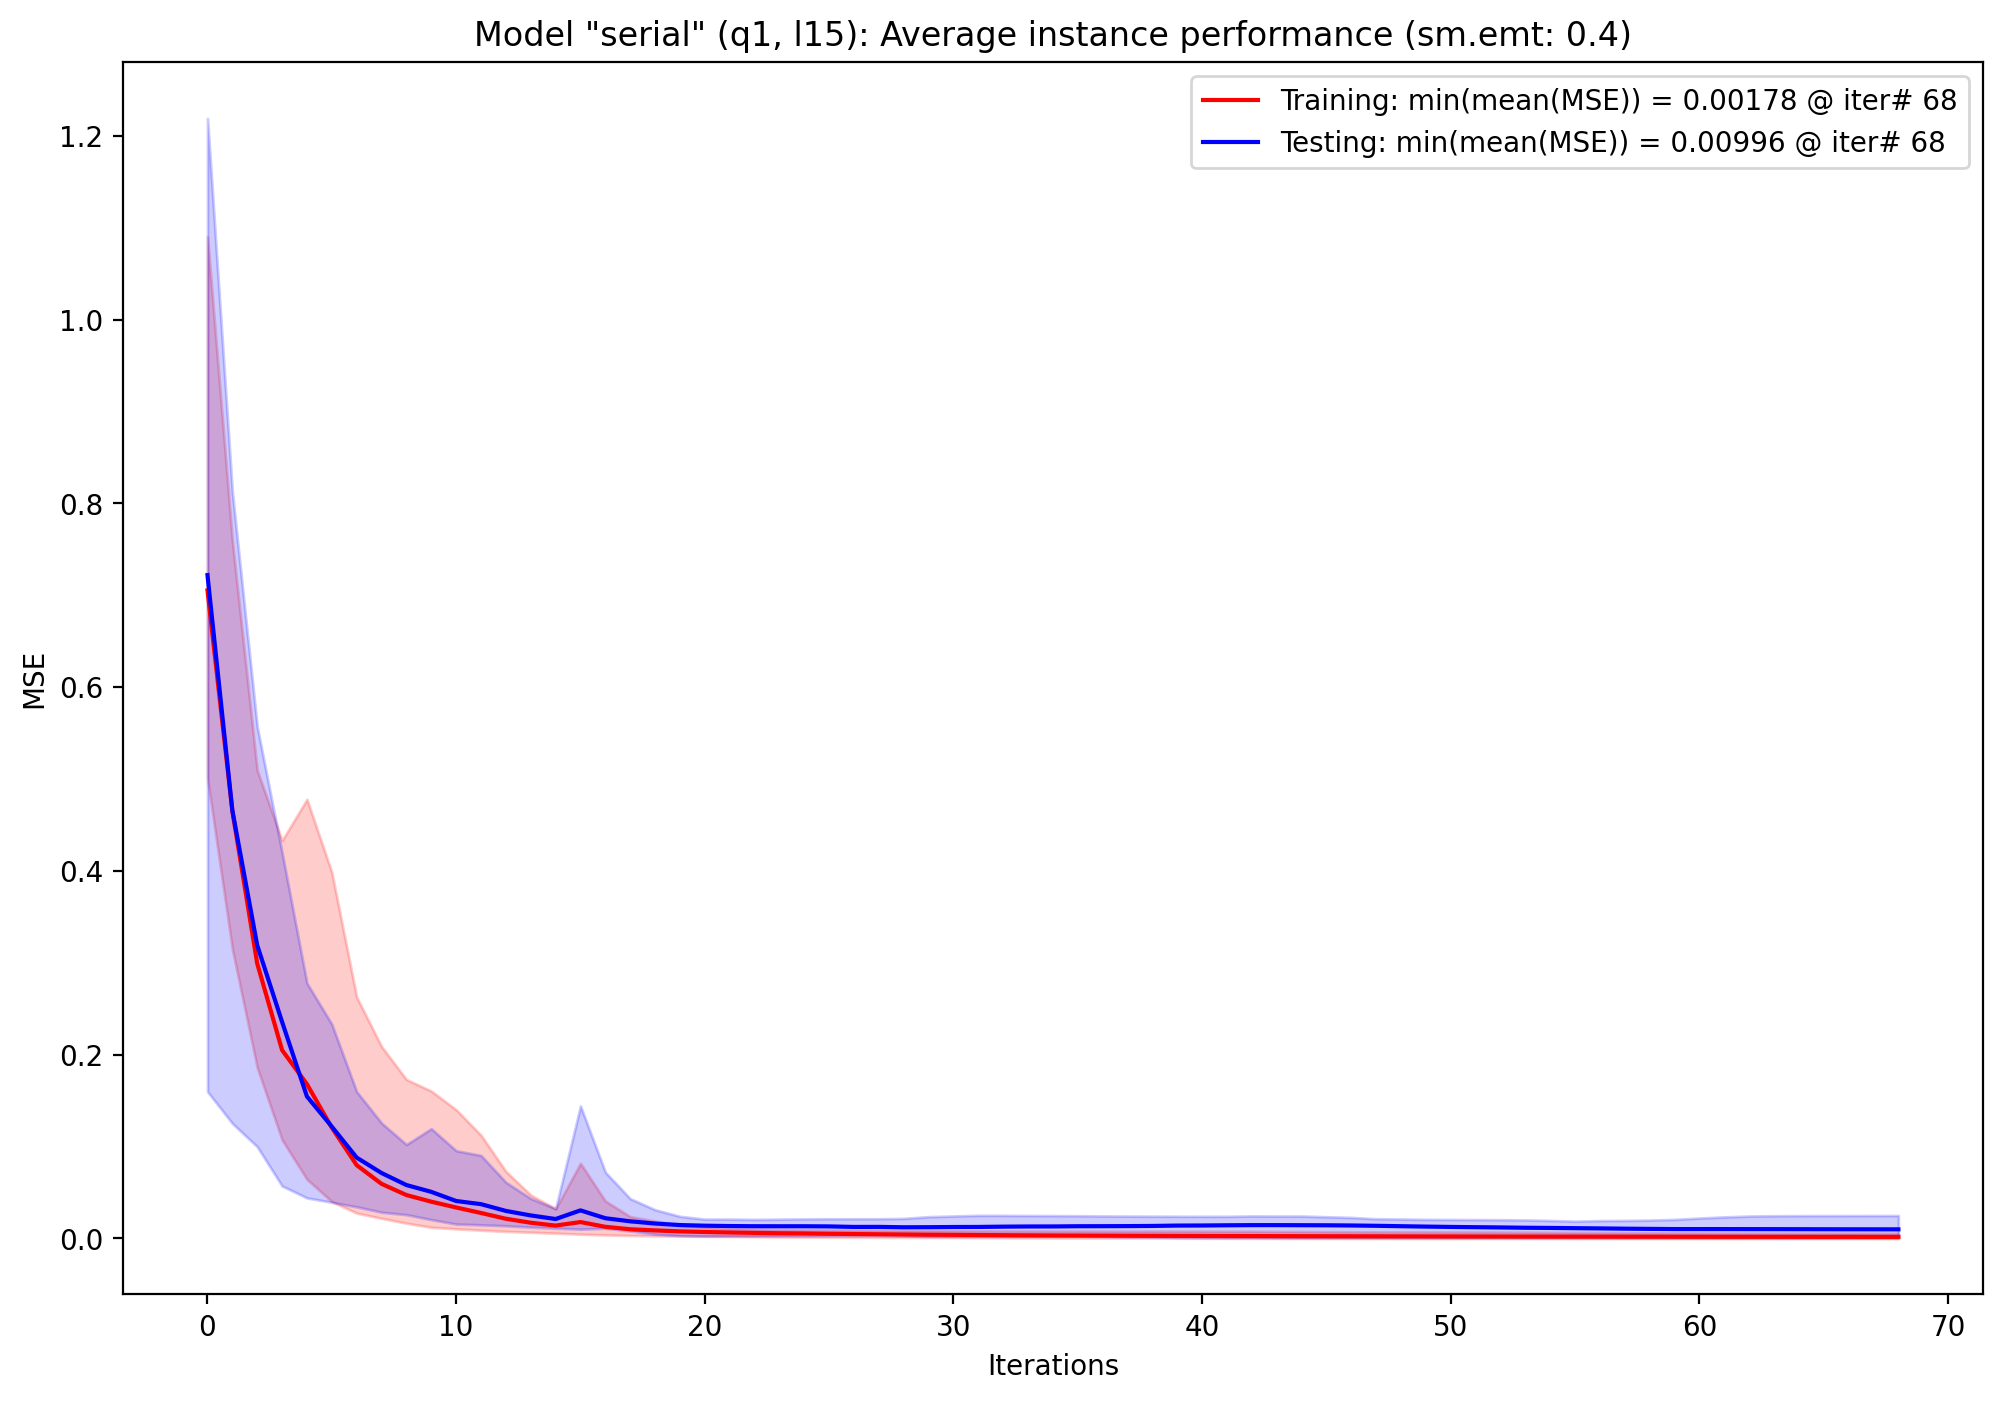

In [17]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_l{layers}_inst_perform_mse_range.png'
plot_objfn_range([[np.array(x) for x in insts_train_mse_scores], [np.array(x) for x in insts_test_mse_scores]], 
    objfn_list=['Training', 'Testing'], # xlim=(-1, 40), 
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'MSE', meas_type='mean(MSE)',
    title=f'Model "{CASE_NAME}" (q{qubits}, l{layers}): '+
        f'Average instance performance (sm.emt: {smooth_weight})', 
    rcParams=(12, 8), dpi=200, save_plot=range_plot_path
    )

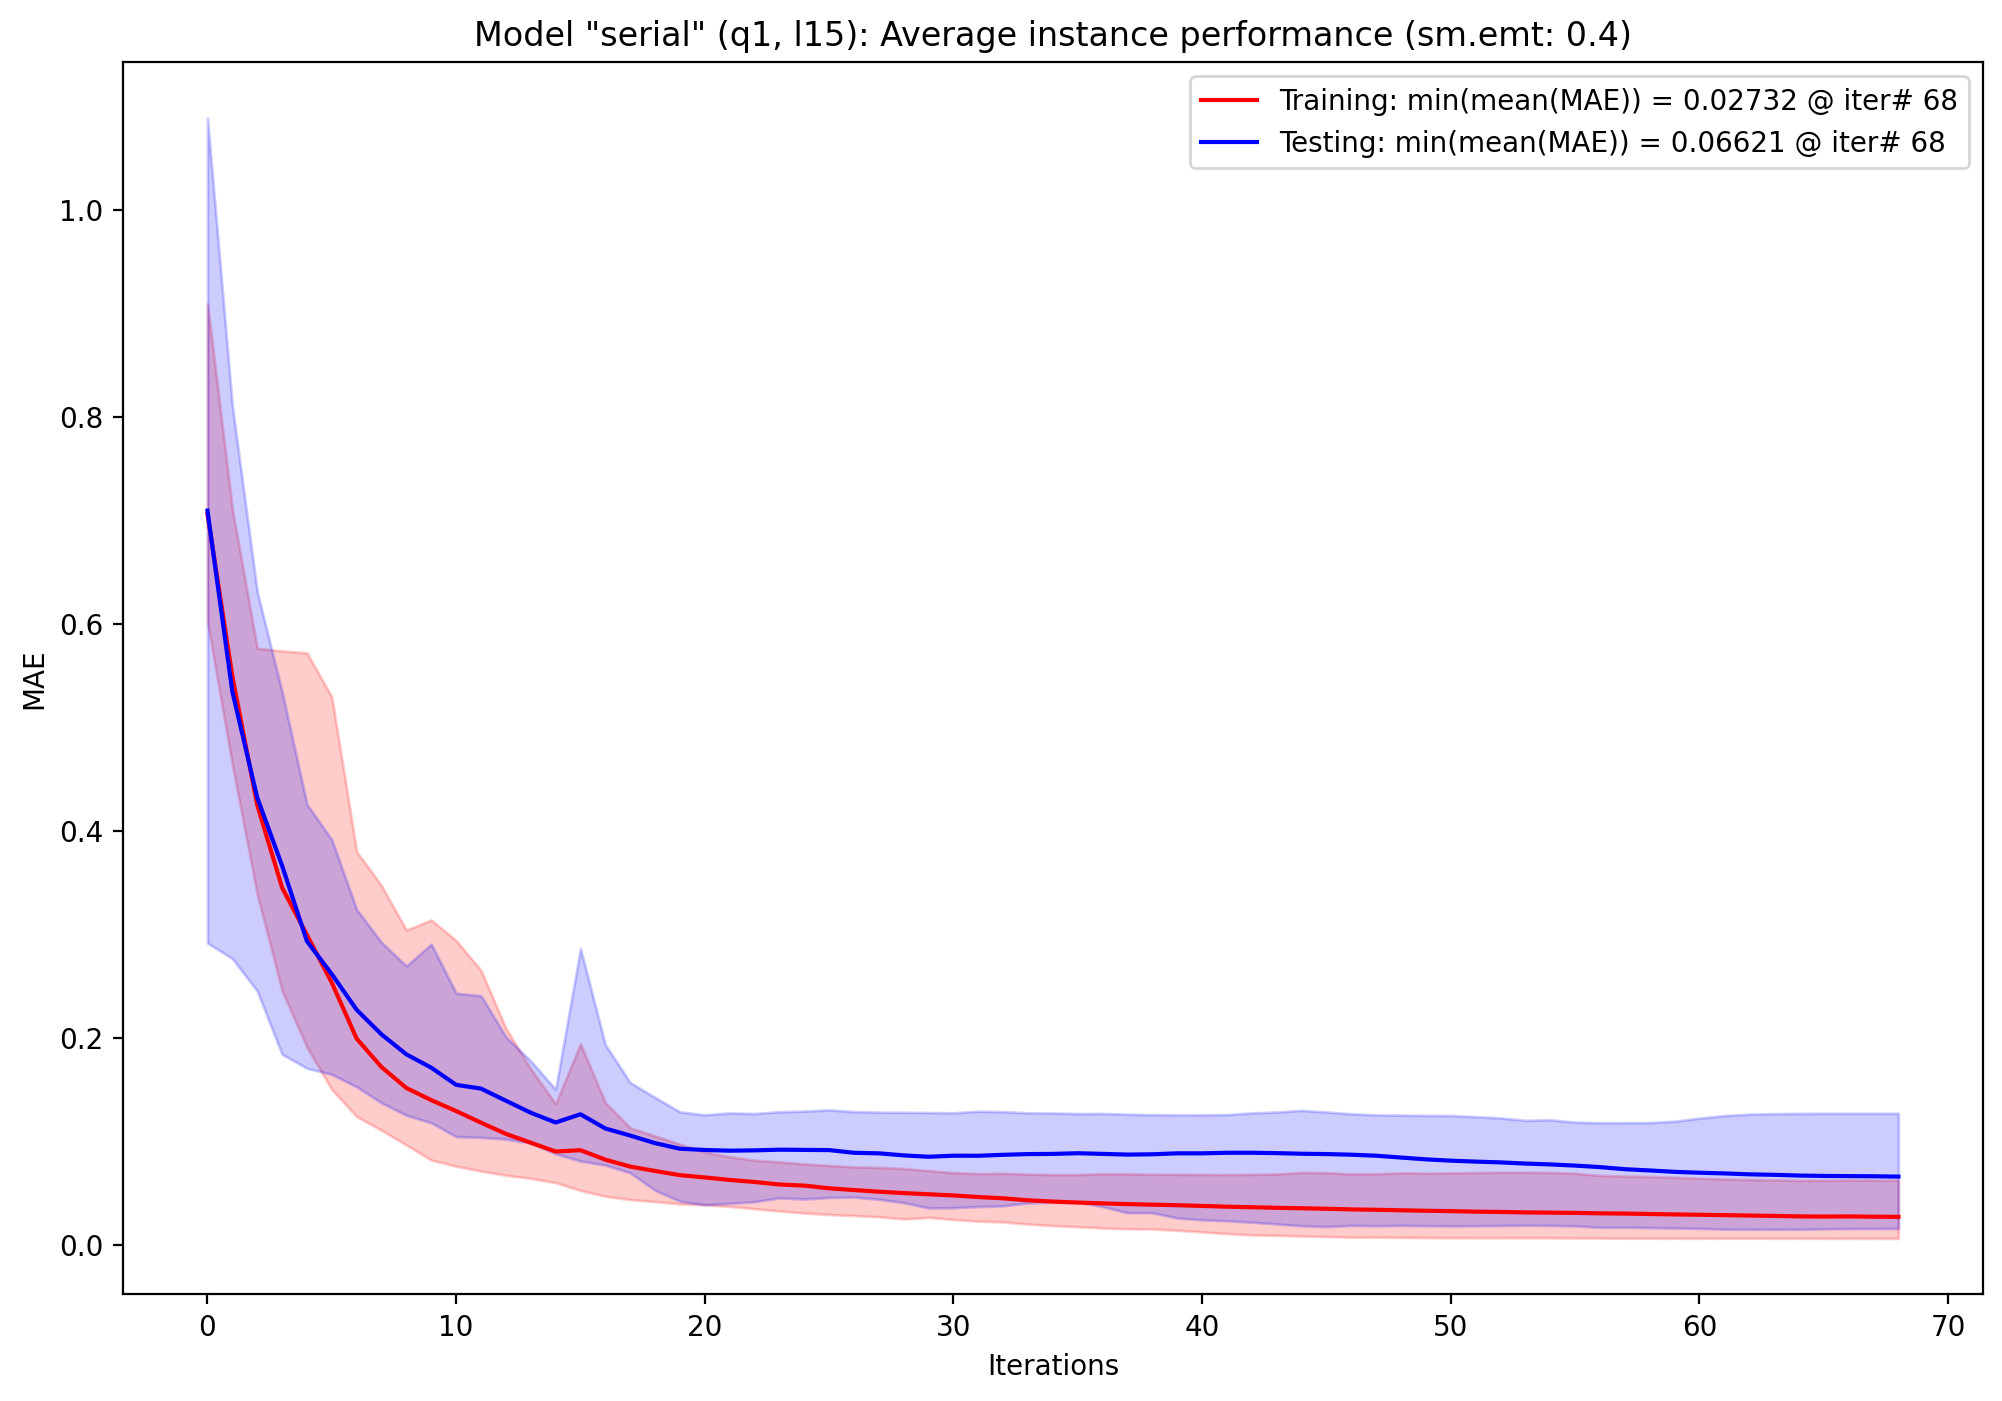

In [18]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_l{layers}_inst_perform_mae_range.png'
plot_objfn_range([[np.array(x) for x in insts_train_mae_scores], [np.array(x) for x in insts_test_mae_scores]], 
    objfn_list=['Training', 'Testing'], # xlim=(-1, 40), 
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'MAE', meas_type='mean(MAE)',
    title=f'Model "{CASE_NAME}" (q{qubits}, l{layers}): '+
        f'Average instance performance (sm.emt: {smooth_weight})', 
    rcParams=(12, 8), dpi=200, save_plot=range_plot_path
    )

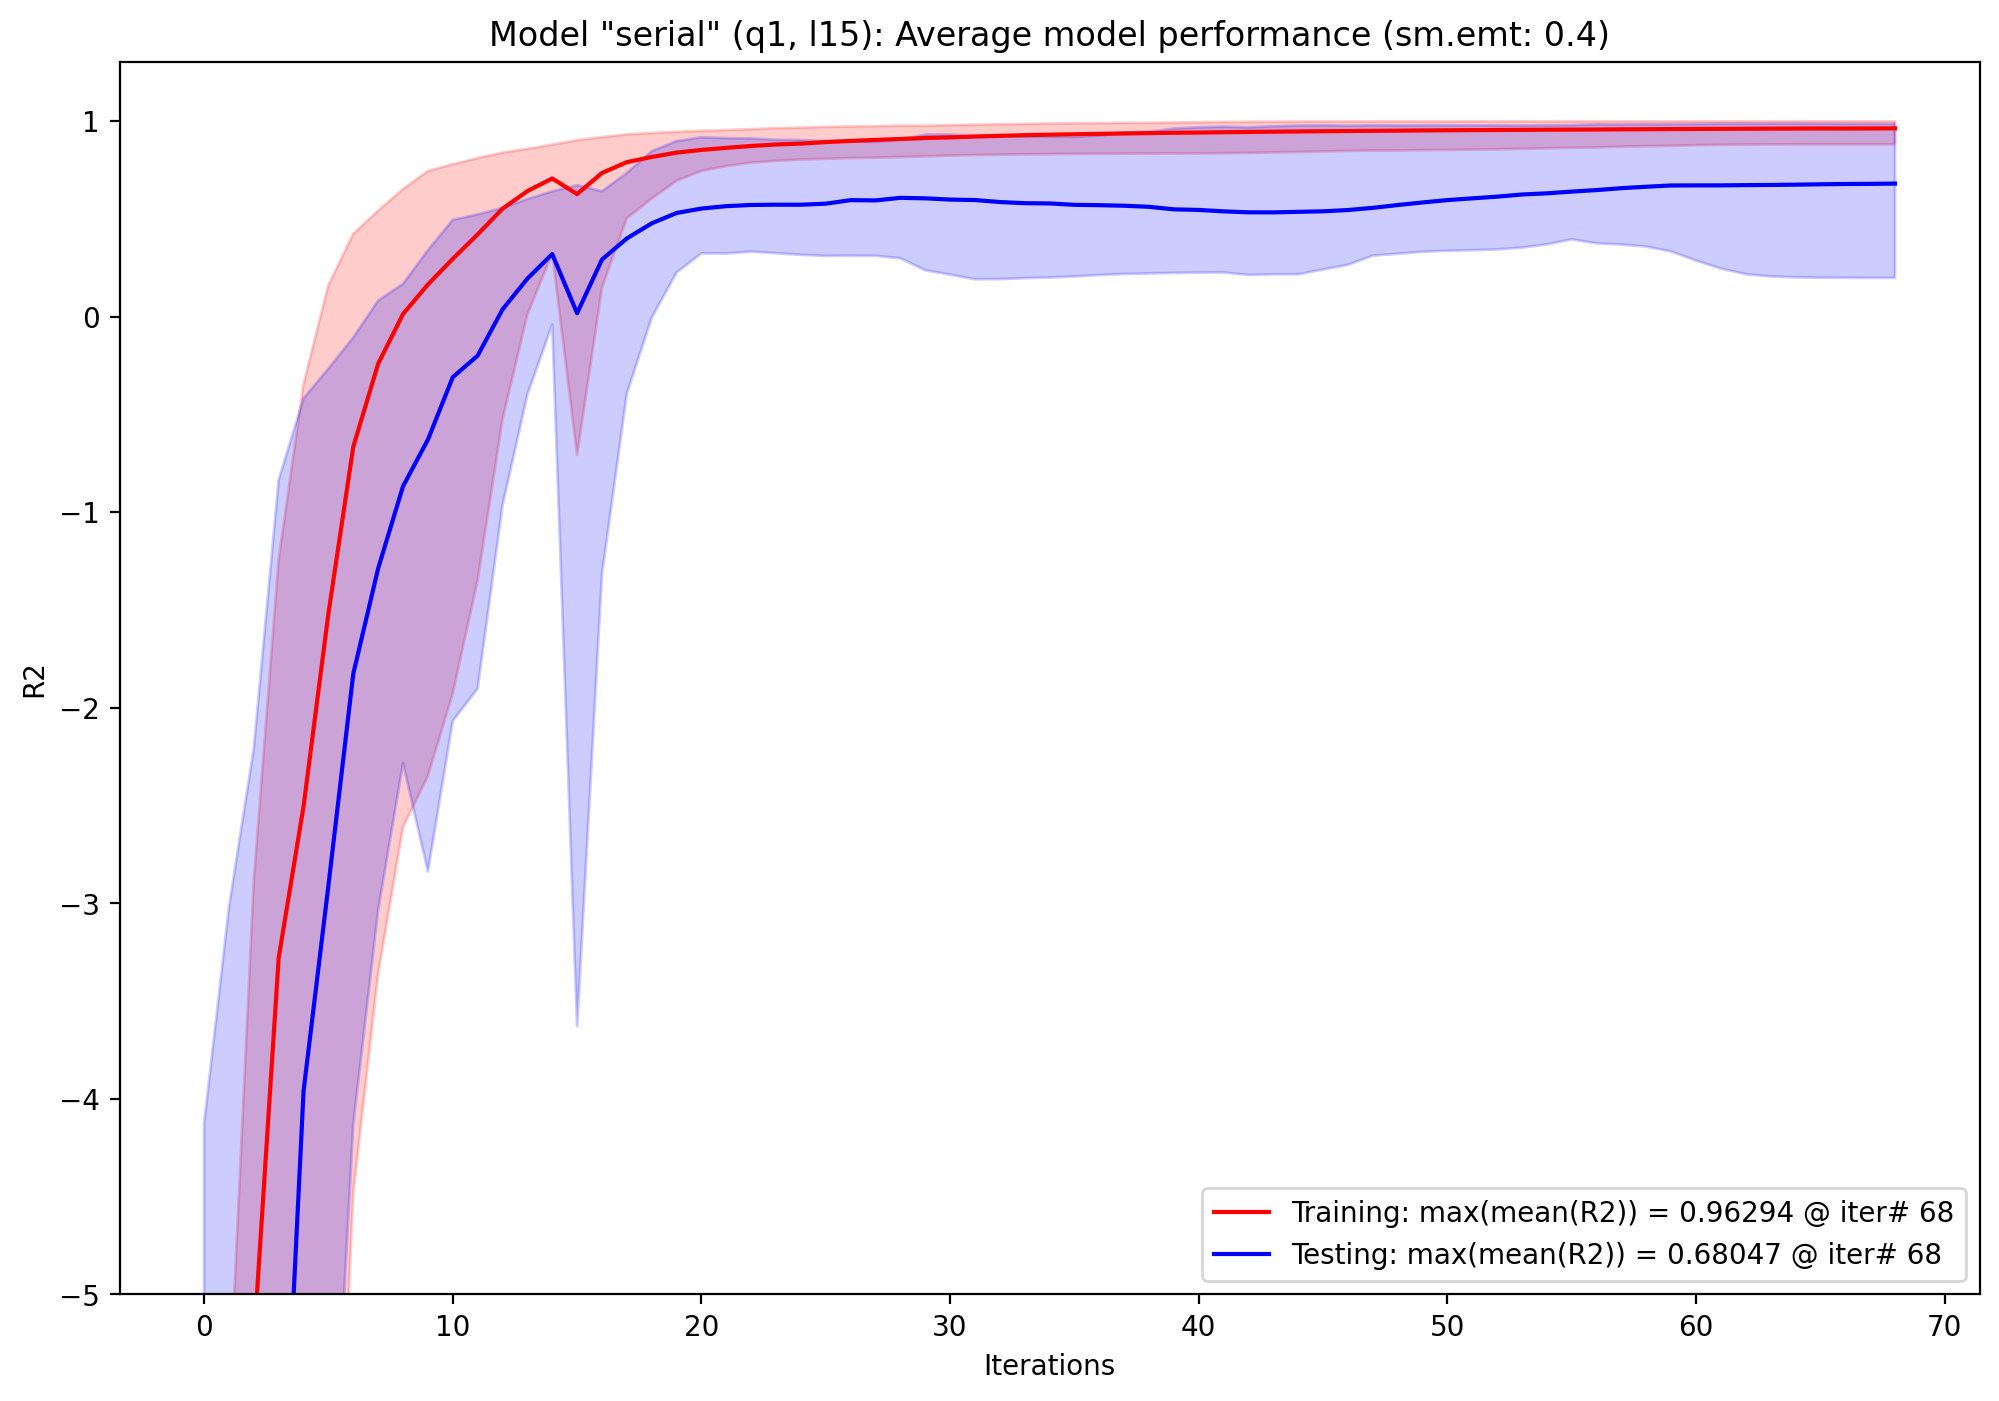

In [30]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
smooth_weight=0.4
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_l{layers}_inst_perform_r2_range.png'
plot_objfn_range([[np.array(x) for x in insts_train_r2_scores], [np.array(x) for x in insts_test_r2_scores]], 
    objfn_list=['Training', 'Testing'], meas_min=False, ylim=(-5, 1.3), #xlim=(-1, 40),
    smooth_weight=smooth_weight, log_interv=log_interv, ylabel=f'R2', meas_type='mean(R2)',
    title=f'Model "{CASE_NAME}" (q{qubits}, l{layers}): Average model performance (sm.emt: {smooth_weight})', 
    rcParams=(12, 8), dpi=200, save_plot=range_plot_path
    )

## Plot the model instance with the best minimum test MSE

In [20]:
### Find the instance with the best (min) minimum MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_min_test_score = np.min(insts_test_min_mse_scores)
sel_inst = int(np.argmin(insts_test_min_mse_scores))
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with the best test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_min_test_score, 5)}\n')


Instance with the best test MSE: 6 @ itr(61) = 0.00038



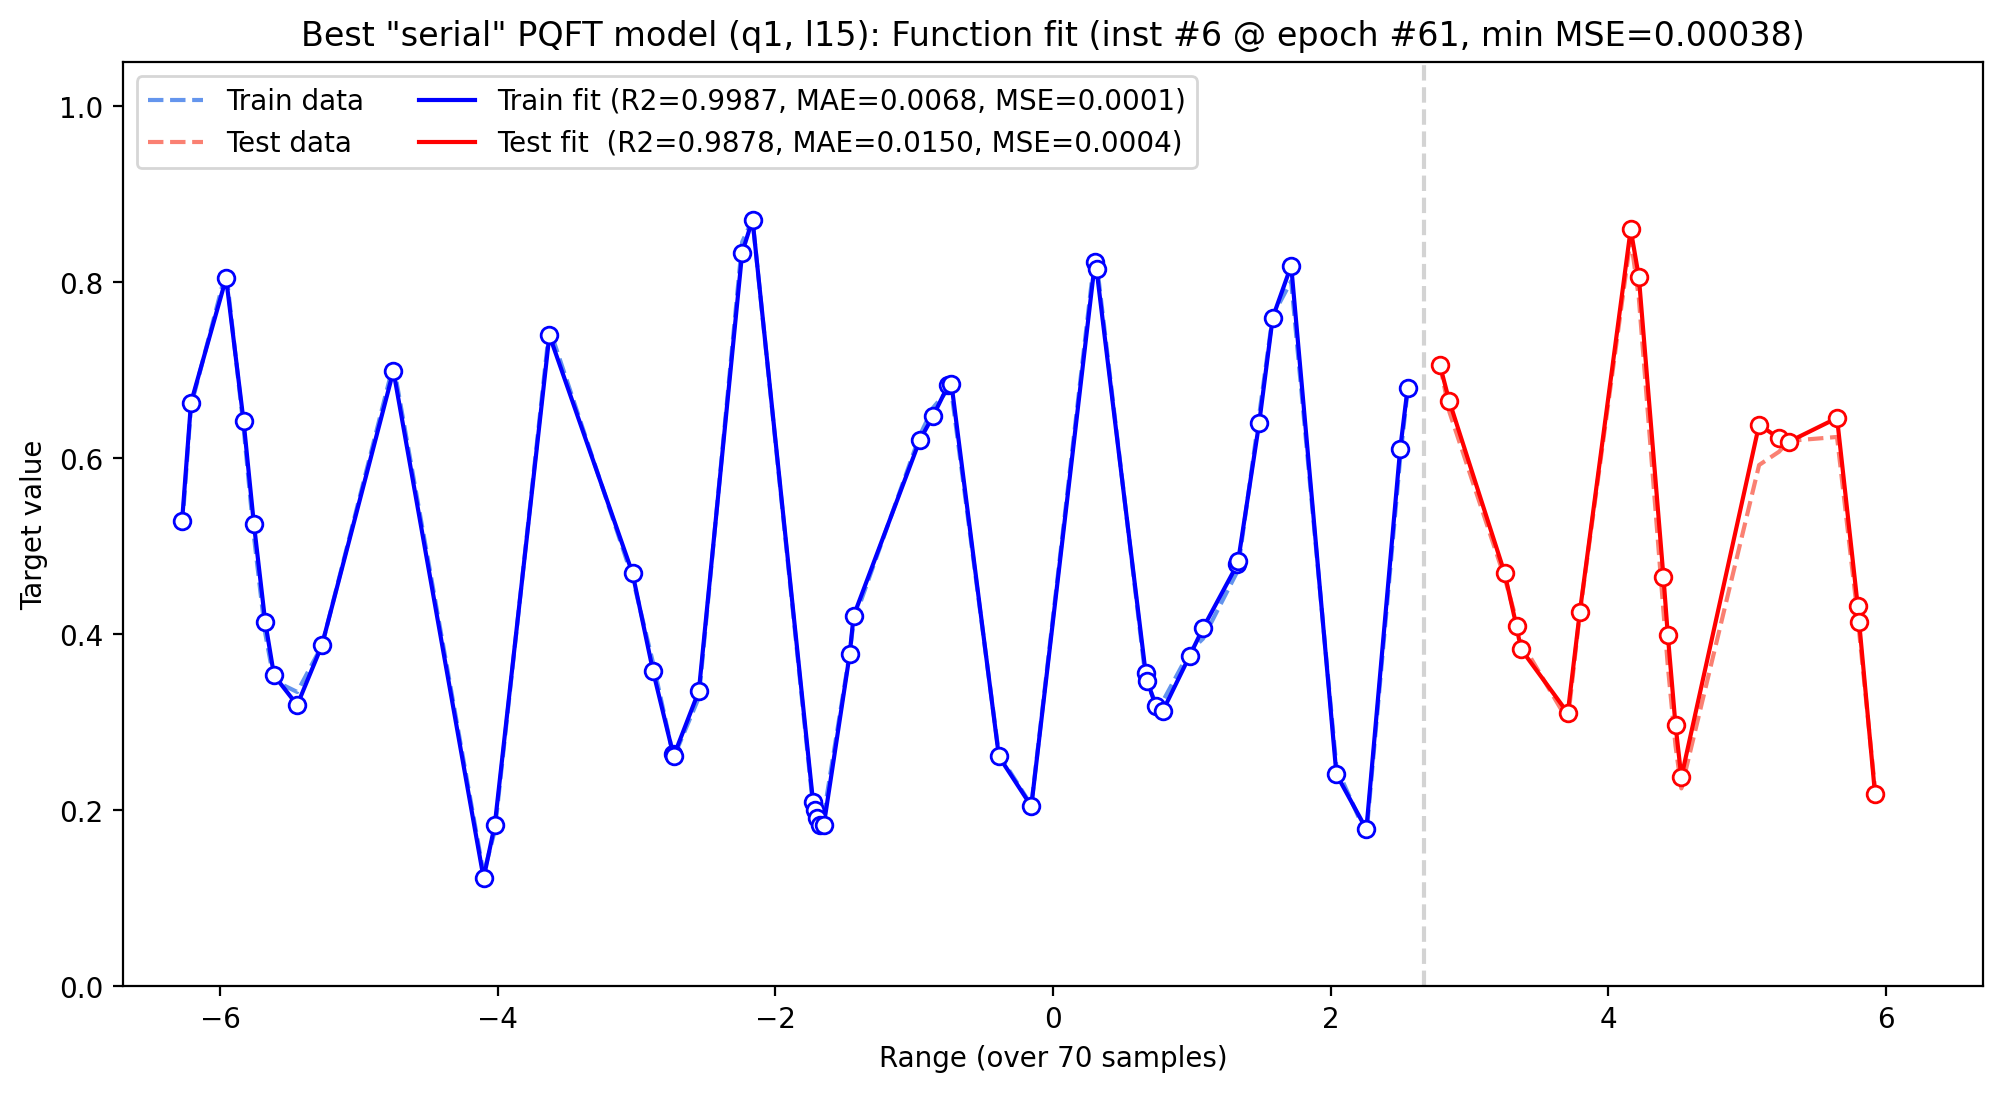

In [21]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_hat = insts_train_preds[sel_inst][sel_params_no]
y_test_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/'+\
    f'xfig_anlz_{CASE_NAME}_q{qubits}_l{layers}_fitmin_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}.eps'
plot_train_and_test_data(
    X_all, y_all, X_train, y_train, X_valid, y_valid, y_train_hat, y_test_hat,
    legend_cols=2, xlim=(-6.7, 6.7), ylim=(0, 1.05), # legend_loc='lower right', 
    colors=['orange', 'cornflowerblue', 'salmon', 'blue', 'red'], 
    linestyles=['none', 'dashed', 'dashed', 'solid', 'solid'],
    marker='o', xlabel=f'Range (over {samples} samples)',
    title=f'Best "{CASE_NAME}" PQFT model (q{qubits}, l{layers}): Function fit (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={np.round(sel_min_test_score, 5)})',
    labels=['Fun', 'Train data', 'Test data', 
            f'Train fit (R2={np.round(train_r2, 4):0.4f}, MAE={np.round(train_mae, 4):0.4f}, MSE={np.round(train_mse, 4):0.4f})', 
            f'Test fit  (R2={np.round(test_r2, 4):0.4f}, MAE={np.round(test_mae, 4):0.4f}, MSE={np.round(test_mse, 4):0.4f})'],
    rcParams=(12, 6), dpi=200,
    save_plot=anlz_fit_path
)

## Plot the model instance with the median minimum test MSE

In [22]:
### Find the median and its location in a list
def arg_median(lst):
    sorted_lst = sorted(lst)
    n = len(sorted_lst)
    if n % 2 == 1: # odd number of elements, the median is the middle element
        median_value = sorted_lst[n // 2]
    else: # even number of elements, the median is the average of the two middle elements
        median_value = sorted_lst[n // 2 - 1]    
    median_index = lst.index(median_value)    
    return median_index, median_value

In [23]:
### Find the instance with the median min MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_inst, sel_median_test_score = arg_median(insts_test_min_mse_scores)
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with median test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_median_test_score, 5)}\n')


Instance with median test MSE: 9 @ itr(31) = 0.00775



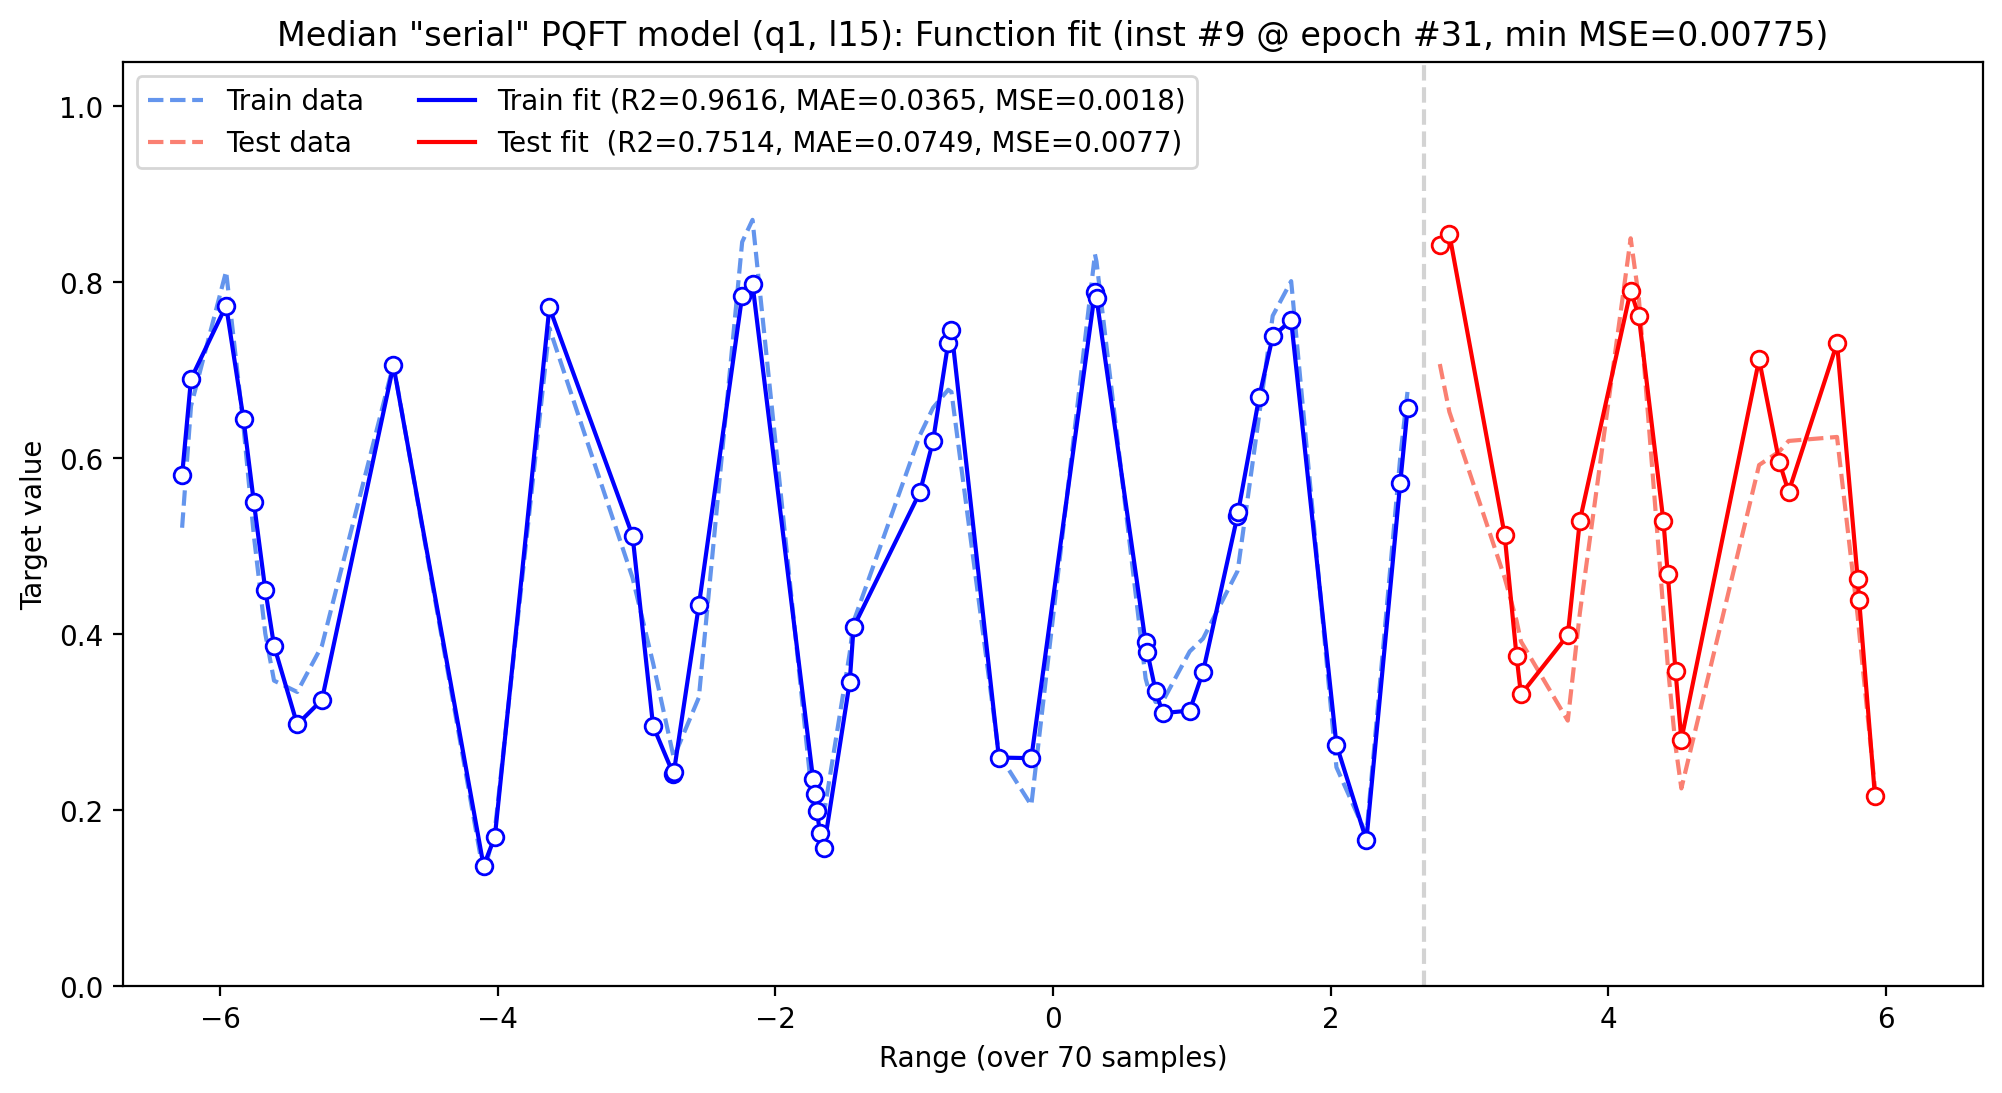

In [24]:
### Plot trainig and validation/test data partitions
### for the model with the median minimum MSE values among all instances

y_train_hat = insts_train_preds[sel_inst][sel_params_no]
y_test_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/'+\
    f'xfig_anlz_{CASE_NAME}_q{qubits}_l{layers}_fitmed_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}.eps'
plot_train_and_test_data(
    X_all, y_all, X_train, y_train, X_valid, y_valid, y_train_hat, y_test_hat,
    legend_cols=2, xlim=(-6.7, 6.7), ylim=(0, 1.05), # legend_loc='lower right', 
    colors=['orange', 'cornflowerblue', 'salmon', 'blue', 'red'], 
    linestyles=['none', 'dashed', 'dashed', 'solid', 'solid'],
    marker='o', xlabel=f'Range (over {samples} samples)',
    title=f'Median "{CASE_NAME}" PQFT model (q{qubits}, l{layers}): Function fit (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={np.round(sel_median_test_score, 5)})',
    rcParams=(12, 6), dpi=200,
    labels=['Fun', 'Train data', 'Test data', 
            f'Train fit (R2={np.round(train_r2, 4):0.4f}, MAE={np.round(train_mae, 4):0.4f}, MSE={np.round(train_mse, 4):0.4f})', 
            f'Test fit  (R2={np.round(test_r2, 4):0.4f}, MAE={np.round(test_mae, 4):0.4f}, MSE={np.round(test_mse, 4):0.4f})'],
    save_plot=anlz_fit_path
)

## Plot the model instance with the worst minimum test MSE

In [25]:
### Find the instance with the worst (max) minimum MSE score
insts_test_min_mse_scores = [float(np.min(inst_mses)) for inst_mses in insts_test_mse_scores]
sel_max_test_score = np.max(insts_test_min_mse_scores)
sel_inst = int(np.argmax(insts_test_min_mse_scores))
sel_params_no = int(np.argmin(insts_test_mse_scores[sel_inst]))
print(f'\nInstance with the worst test MSE: {sel_inst} @ itr({sel_params_no}) = {round(sel_max_test_score, 5)}\n')


Instance with the worst test MSE: 8 @ itr(15) = 0.01597



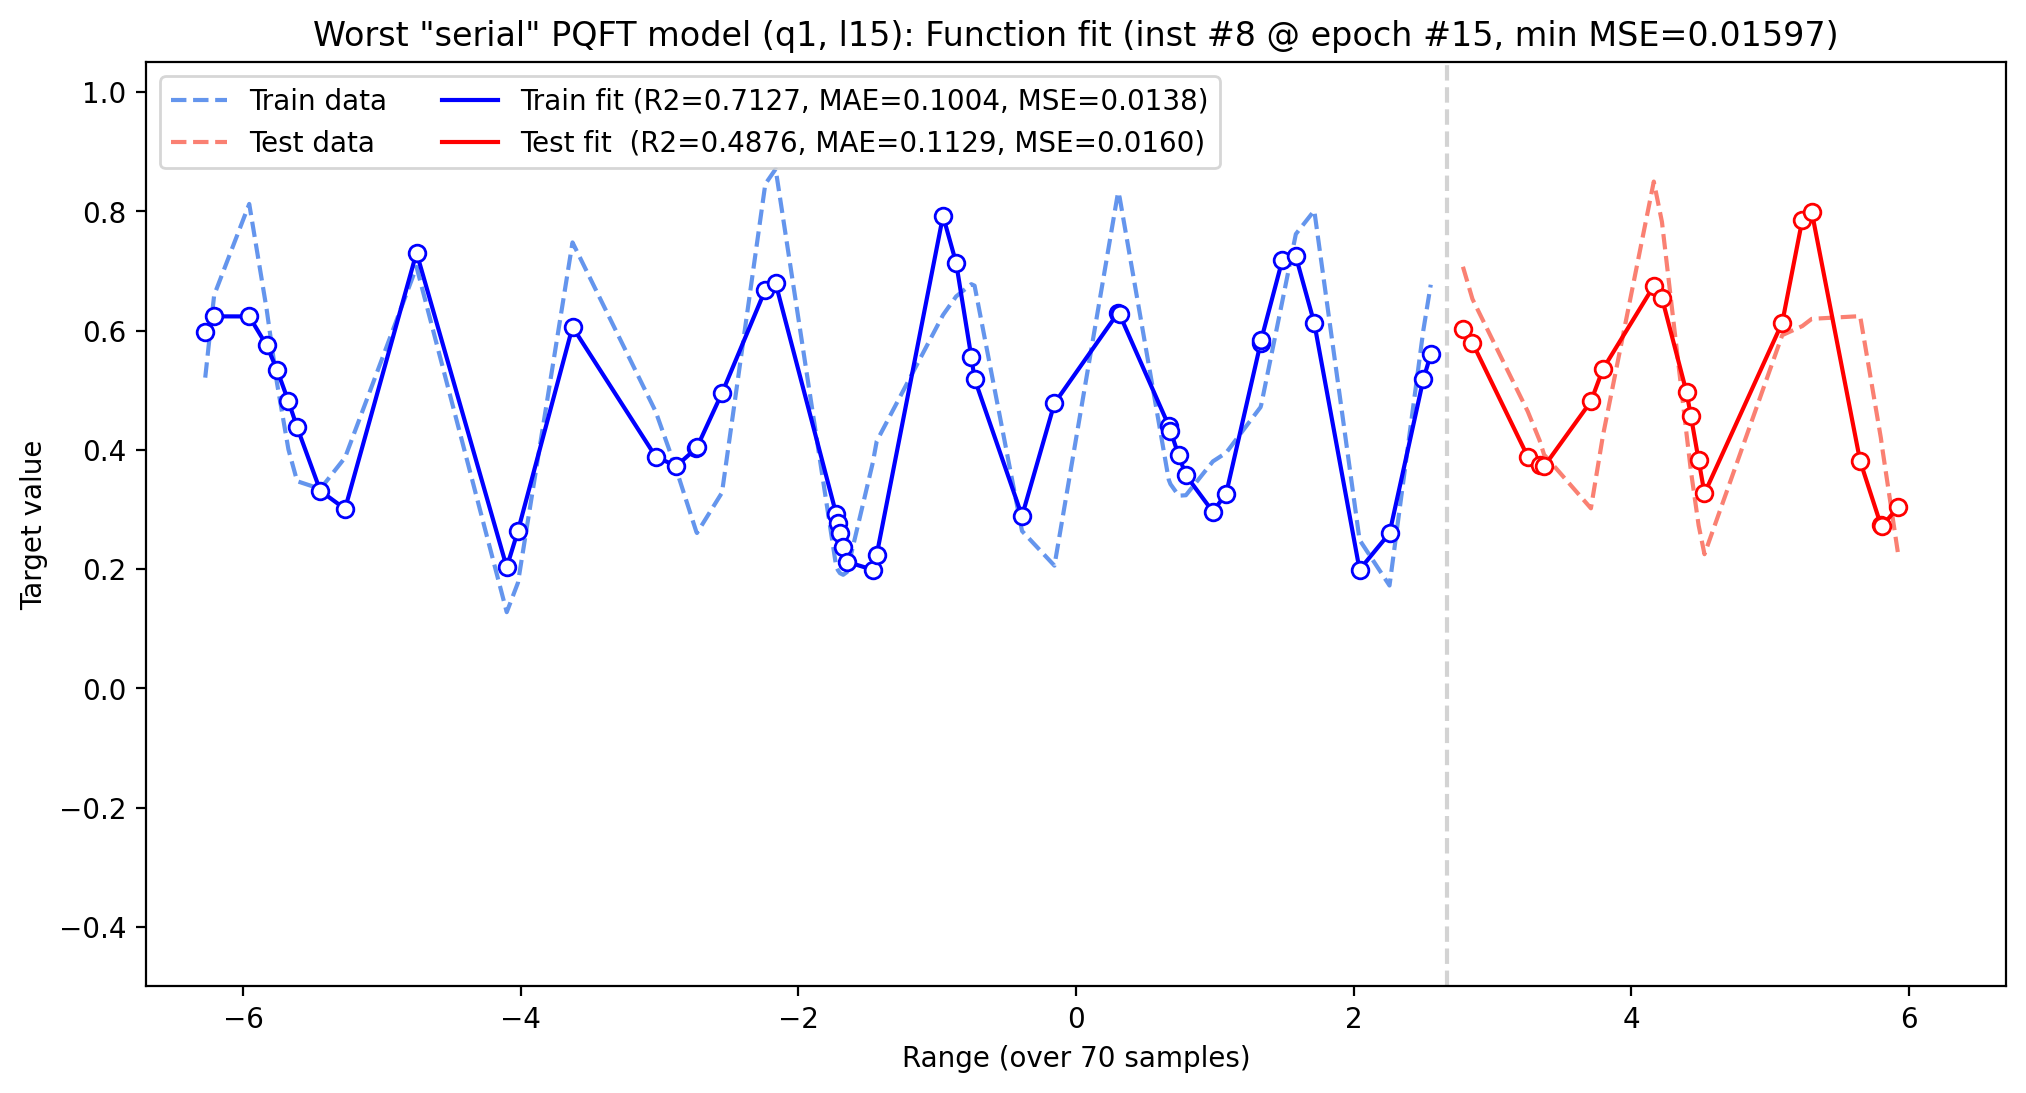

In [26]:
### Plot trainig and validation/test data partitions
### for the model with the median minimum MSE values among all instances

y_train_hat = insts_train_preds[sel_inst][sel_params_no]
y_test_hat = insts_test_preds[sel_inst][sel_params_no]
train_r2 = insts_train_r2_scores[sel_inst][sel_params_no]
train_mae = insts_train_mae_scores[sel_inst][sel_params_no]
train_mse = insts_train_mse_scores[sel_inst][sel_params_no]
test_r2 = insts_test_r2_scores[sel_inst][sel_params_no]
test_mae = insts_test_mae_scores[sel_inst][sel_params_no]
test_mse = insts_test_mse_scores[sel_inst][sel_params_no]

anlz_fit_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/'+\
    f'xfig_anlz_{CASE_NAME}_q{qubits}_l{layers}_fitmax_'+\
    f'inst{sel_inst:03d}_itr{sel_params_no*log_interv:03}.eps'
plot_train_and_test_data(
    X_all, y_all, X_train, y_train, X_valid, y_valid, y_train_hat, y_test_hat,
    legend_cols=2, xlim=(-6.7, 6.7), ylim=(-0.5, 1.05), # legend_loc='lower right', 
    colors=['orange', 'cornflowerblue', 'salmon', 'blue', 'red'], 
    linestyles=['none', 'dashed', 'dashed', 'solid', 'solid'],
    marker='o', xlabel=f'Range (over {samples} samples)',
    title=f'Worst "{CASE_NAME}" PQFT model (q{qubits}, l{layers}): Function fit (inst #{sel_inst} @ epoch #{sel_params_no*log_interv}, min MSE={np.round(sel_max_test_score, 5)})',
    rcParams=(12, 6), dpi=200,
    labels=['Fun', 'Train data', 'Test data', 
            f'Train fit (R2={np.round(train_r2, 4):0.4f}, MAE={np.round(train_mae, 4):0.4f}, MSE={np.round(train_mse, 4):0.4f})', 
            f'Test fit  (R2={np.round(test_r2, 4):0.4f}, MAE={np.round(test_mae, 4):0.4f}, MSE={np.round(test_mse, 4):0.4f})'],
    save_plot=anlz_fit_path
)

## System

In [27]:
import os
import sys
print(f"\nOperating environment:\n")
os.system('lsb_release -d -s')
os.system('python --version')
print(f'Conda {os.path.basename(sys.prefix)}\n')


Operating environment:

Ubuntu 22.04.5 LTS
Python 3.11.11
Conda qiskit-gpu



In [28]:
print(f"\nSignificant Python packages:\n")
os.system('pip list | grep -e qiskit');


Significant Python packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
